# Diagnóstico Econométrico — 130 Ativos B3 (2010–2025)
**TCC: Moderna Teoria das Carteiras no Mercado Acionário Brasileiro**  
**Autor:** Pedro Augusto Pinheiro Reis | UFG — Ciências Contábeis  

---
**Correções aplicadas em relação à versão anterior:**
- Input: leitura do CSV original (sep=';', decimal=',') em vez do parquet inexistente
- `dropna(how='all')` no cálculo de retornos — preserva cada ativo com sua série completa
- IQR multiplicador 1.5 (Tukey padrão) — declarado explicitamente
- Ljung-Box consistente em retornos brutos em todo o notebook
- Chow test incluído no batch para os 130 ativos nas 4 datas economicamente relevantes

**Testes realizados:**
1. Estatísticas Descritivas + Jarque-Bera (normalidade)
2. ADF (preços e log-retornos) + KPSS (log-retornos)
3. Ljung-Box Q(10) em log-retornos brutos
4. ARCH LM de Engle em resíduos AR(1)
5. Variance Ratio — Lo & MacKinlay (1988)
6. Chow — Quebra estrutural (2015, 2016, 2020, 2022)
7. CUSUM (5 ativos representativos)
8. Tabela síntese consolidada + exportação CSV

# Diagnóstico Econométrico — 130 Ativos B3 (2010–2025)
**TCC: Moderna Teoria das Carteiras no Mercado Acionário Brasileiro**  
**Autor:** Pedro Augusto Pinheiro Reis | UFG — Ciências Contábeis  

---
**Correções aplicadas em relação à versão anterior:**
- Input: leitura do CSV original (sep=';', decimal=',') em vez do parquet inexistente
- `dropna(how='all')` no cálculo de retornos — preserva cada ativo com sua série completa
- IQR multiplicador 1.5 (Tukey padrão) — declarado explicitamente
- Ljung-Box consistente em retornos brutos em todo o notebook
- Chow test incluído no batch para os 130 ativos nas 4 datas economicamente relevantes

**Testes realizados:**
1. Estatísticas Descritivas + Jarque-Bera (normalidade)
2. ADF (preços e log-retornos) + KPSS (log-retornos)
3. Ljung-Box Q(10) em log-retornos brutos
4. ARCH LM de Engle em resíduos AR(1)
5. Variance Ratio — Lo & MacKinlay (1988)
6. Chow — Quebra estrutural (2015, 2016, 2020, 2022)
7. CUSUM (5 ativos representativos)
8. Tabela síntese consolidada + exportação CSV

In [2]:
%pip install statsmodels pandas numpy scipy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ============================================================
# CÉLULA 1 — INSTALAÇÕES E IMPORTAÇÕES
# ============================================================


import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import breaks_cusumolsresid

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'figure.dpi': 130, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

print('✅ Dependências carregadas.')

✅ Dependências carregadas.


In [5]:
# ============================================================
# CÉLULA 2 — CONFIGURAÇÃO DE CAMINHOS
# ============================================================
# AJUSTE AQUI conforme seu ambiente

PASTA_DADOS      = r'C:\VSCodeWorkspace\TCC_Final\data'
PASTA_RESULTADOS = r'C:\VSCodeWorkspace\TCC_Final\results\diagnostico'
os.makedirs(PASTA_RESULTADOS, exist_ok=True)

# ── Input principal ──────────────────────────────────────────
# CORREÇÃO 1: leitura do CSV original, não do parquet inexistente
ARQUIVO_PRECOS = os.path.join(
    PASTA_DADOS,
    'lista_economatica_dados_Jan_2010_Dezembro_2025.csv'
)

# ── Parâmetros ──────────────────────────────────────────────
COBERTURA_MINIMA = 0.95   # ativos com >= 95% dos pregões
ALPHA            = 0.05   # nível de significância
IQR_MULT         = 1.5    # multiplicador IQR para outliers (Tukey padrão)
                          # NOTA: o Cap. 3 da sanitização usa 3.0 (conservador).
                          # Aqui usamos 1.5 para diagnóstico estatístico.
                          # Ambos são defensáveis; declarar no TCC qual critério
                          # foi usado em cada etapa.

# Datas de quebra estrutural a testar (Chow)
DATAS_CHOW = {
    'Crise_BR_2015'    : '2015-01-01',
    'Impeachment_2016' : '2016-04-01',
    'COVID_2020'       : '2020-03-01',
    'Juros_2022'       : '2022-01-01',
}

print(f'Pasta de dados:   {PASTA_DADOS}')
print(f'Pasta resultados: {PASTA_RESULTADOS}')
print(f'Cobertura mínima: {COBERTURA_MINIMA:.0%}')
print(f'IQR multiplicador: {IQR_MULT}')

Pasta de dados:   C:\VSCodeWorkspace\TCC_Final\data
Pasta resultados: C:\VSCodeWorkspace\TCC_Final\results\diagnostico
Cobertura mínima: 95%
IQR multiplicador: 1.5


In [6]:
# ============================================================
# CÉLULA 3 — CARREGAMENTO E FILTRAGEM DOS DADOS
# ============================================================
# CORREÇÃO 1: sep=';', decimal=',' — formato Economática brasileiro

print('Carregando base de preços...')
df_raw = pd.read_csv(
    ARQUIVO_PRECOS,
    sep=';',
    decimal=',',
    encoding='utf-8'
)

# Indexar pela data
df_raw.rename(columns={df_raw.columns[0]: 'Data'}, inplace=True)
df_raw['Data'] = pd.to_datetime(df_raw['Data'], dayfirst=True, errors='coerce')
df_raw = df_raw.dropna(subset=['Data']).set_index('Data').sort_index()
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

# ── Filtrar 130 ativos com >= 95% de cobertura ──────────────
cobertura    = 1 - df_raw.isna().mean()
ativos_130   = sorted(cobertura[cobertura >= COBERTURA_MINIMA].index.tolist())
df_precos    = df_raw[ativos_130].copy()

# ── Forward-fill + backward-fill (NaN por não-negociação) ───
nan_antes    = df_precos.isna().sum().sum()
df_precos    = df_precos.ffill().bfill()
nan_depois   = df_precos.isna().sum().sum()

print(f'Shape bruto: {df_raw.shape}')
print(f'Ativos com >= {COBERTURA_MINIMA:.0%}: {len(ativos_130)}')
print(f'Período: {df_precos.index[0].date()} → {df_precos.index[-1].date()}')
print(f'NaN tratados (ffill+bfill): {nan_antes - nan_depois:,}')
print(f'NaN remanescentes: {nan_depois}')

if nan_depois > 0:
    print('⚠️ Ativos com NaN remanescente:')
    print(df_precos.isna().sum()[df_precos.isna().sum() > 0])
else:
    print('✅ Base limpa — sem NaN remanescentes.')

Carregando base de preços...
Shape bruto: (3967, 496)
Ativos com >= 95%: 135
Período: 2010-01-04 → 2025-12-30
NaN tratados (ffill+bfill): 2,204
NaN remanescentes: 0
✅ Base limpa — sem NaN remanescentes.


In [7]:
# ============================================================
# CÉLULA 4 — CÁLCULO DOS LOG-RETORNOS
# ============================================================
# CORREÇÃO 2: dropna(how='all') preserva cada ativo com sua
# série completa em vez de descartar linhas por NaN de outros ativos.
#
# Por que isso importa:
#   dropna() padrão (any): se ATIVO_X tem NaN na linha t,
#     a linha t é removida de TODOS os 130 ativos.
#   dropna(how='all'): remove linha apenas se TODOS os ativos
#     forem NaN naquela data — muito mais conservador.
#
# Como os preços já foram tratados com ffill+bfill, na prática
# não haverá diferença aqui — mas a correção garante robustez
# em qualquer reexecução sobre dados sem pré-tratamento.

df_log_ret = np.log(df_precos / df_precos.shift(1))
df_log_ret = df_log_ret.dropna(how='all')   # CORREÇÃO 2

print(f'Log-retornos: {df_log_ret.shape}')
print(f'Período: {df_log_ret.index[0].date()} → {df_log_ret.index[-1].date()}')
print(f'NaN nos log-retornos: {df_log_ret.isna().sum().sum()}')

Log-retornos: (3966, 135)
Período: 2010-01-05 → 2025-12-30
NaN nos log-retornos: 0


In [8]:
# ============================================================
# CÉLULA 5 — FUNÇÕES AUXILIARES
# ============================================================

def teste_variance_ratio(series, q=5):
    """
    Teste de Razão de Variância de Lo & MacKinlay (1988).
    H0: Passeio Aleatório (VR = 1).
    Fórmula homoscedástica — adequada para diagnóstico geral.
    Validada contra séries RW, AR(1) e mean-reverting.
    """
    s = series.dropna().values
    n = len(s)
    mu = np.mean(s)
    var_1 = np.sum((s - mu) ** 2) / (n - 1)
    rq = np.array([np.sum(s[i - q + 1:i + 1]) for i in range(q - 1, n)])
    m  = q * (n - q + 1) * (1 - q / n)
    var_q = np.sum((rq - q * mu) ** 2) / m
    vr = var_q / var_1 if var_1 > 0 else np.nan
    phi = (2 * (2 * q - 1) * (q - 1)) / (3 * q * n)
    z   = (vr - 1) / np.sqrt(phi) if phi > 0 else np.nan
    p   = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    return vr, z, p


def teste_chow_media(serie, data_quebra):
    """
    Teste de Chow para quebra na MÉDIA dos log-retornos.
    Usa t-test de Welch (não pressupõe igualdade de variâncias).
    H0: sem quebra na média.
    """
    s  = serie.dropna()
    s1 = s[s.index < data_quebra]
    s2 = s[s.index >= data_quebra]
    if len(s1) < 30 or len(s2) < 30:
        return np.nan, np.nan
    t, p = stats.ttest_ind(s1, s2, equal_var=False)
    return abs(t), p


def teste_chow_variancia(serie, data_quebra):
    """
    Teste de Levene para quebra na VARIÂNCIA dos log-retornos.
    H0: sem quebra na variância.
    """
    s  = serie.dropna()
    s1 = s[s.index < data_quebra]
    s2 = s[s.index >= data_quebra]
    if len(s1) < 30 or len(s2) < 30:
        return np.nan, np.nan
    f, p = stats.levene(s1, s2)
    return f, p


def calcular_outliers_iqr(serie, mult=IQR_MULT):
    """Retorna IQR e % de outliers pelo critério de Tukey (mult × IQR)."""
    s   = serie.dropna()
    q75, q25 = np.percentile(s, [75, 25])
    iqr = q75 - q25
    out = ((s > q75 + mult * iqr) | (s < q25 - mult * iqr)).sum()
    return iqr, (out / len(s)) * 100


print('✅ Funções auxiliares definidas.')

✅ Funções auxiliares definidas.


In [9]:
# ============================================================
# CÉLULA 6 — EXEMPLO VISUAL: PETR4 (diagnóstico completo)
# ============================================================
# CORREÇÃO 3: Ljung-Box aplicado a retornos BRUTOS (não resíduos AR(1))
# Isso é consistente com o batch da célula 7.
# O ARCH LM continua sendo aplicado sobre resíduos AR(1) — correto.

ATIVO_EX = 'PETR4'
precos_ex = df_precos[ATIVO_EX].dropna()
ret_ex    = df_log_ret[ATIVO_EX].dropna()

# ── 1. ADF em Preços ──
adf_p = adfuller(precos_ex, regression='c')
print(f'[1] ADF em Preços {ATIVO_EX}:')
print(f'    stat={adf_p[0]:.4f}, p={adf_p[1]:.4f}'
      f' → {"Não-estacionário ✗" if adf_p[1] >= ALPHA else "Estacionário ✓"}')

# ── 2. ADF em Log-Retornos ──
adf_r = adfuller(ret_ex, regression='c')
print(f'[2] ADF em Log-Retornos {ATIVO_EX}:')
print(f'    stat={adf_r[0]:.4f}, p={adf_r[1]:.4f}'
      f' → {"Estacionário ✓" if adf_r[1] < ALPHA else "Não-estacionário ✗"}')

# ── 3. KPSS em Log-Retornos ──
kpss_r = kpss(ret_ex, regression='c', nlags='auto')
print(f'[3] KPSS em Log-Retornos {ATIVO_EX}:')
print(f'    stat={kpss_r[0]:.4f}, p≈{kpss_r[1]:.4f}'
      f' → {"Estacionário ✓" if kpss_r[1] >= ALPHA else "Estacionaridade fraca ⚠"}')

# ── 4. Ljung-Box em Retornos BRUTOS (CORREÇÃO 3) ──
lb_bruto = acorr_ljungbox(ret_ex, lags=[5, 10, 20], return_df=True)
print(f'[4] Ljung-Box (retornos brutos) {ATIVO_EX}:')
for lag in [5, 10, 20]:
    q   = lb_bruto.loc[lag, 'lb_stat']
    p   = lb_bruto.loc[lag, 'lb_pvalue']
    sig = '✗' if p < ALPHA else '✓'
    print(f'    lag {lag:2d}: Q={q:.2f}, p={p:.4f} {sig}')

# ── 5. ARCH LM em Resíduos AR(1) — metodologicamente correto ──
ar_fit = sm.tsa.ARIMA(ret_ex, order=(1, 0, 0)).fit()
lm_s, lm_p, _, _ = het_arch(ar_fit.resid, nlags=10)
print(f'[5] ARCH LM (resíduos AR(1)) {ATIVO_EX}:')
print(f'    LM={lm_s:.2f}, p={lm_p:.2e}'
      f' → {"ARCH confirmado ✗" if lm_p < ALPHA else "Sem ARCH ✓"}')

# ── 6. Jarque-Bera ──
jb_s, jb_p = stats.jarque_bera(ret_ex)
print(f'[6] Jarque-Bera {ATIVO_EX}:')
print(f'    stat={jb_s:.0f}, p={jb_p:.2e}'
      f' → {"Não-normal ✗" if jb_p < ALPHA else "Normal ✓"}')

# ── 7. Variance Ratio ──
vr, z_vr, p_vr = teste_variance_ratio(ret_ex, q=5)
print(f'[7] Variance Ratio q=5 {ATIVO_EX}:')
print(f'    VR={vr:.4f}, z={z_vr:.4f}, p={p_vr:.4f}'
      f' → {"Rejeita RW ✗" if p_vr < ALPHA else "Consistente com RW ✓"}')

# ── 8. Chow nas 4 datas ──
print(f'[8] Chow {ATIVO_EX} (média | variância):')
for label, data in DATAS_CHOW.items():
    t_m, p_m = teste_chow_media(ret_ex, data)
    f_v, p_v = teste_chow_variancia(ret_ex, data)
    sig_m = '✗' if p_m < ALPHA else '✓'
    sig_v = '✗' if p_v < ALPHA else '✓'
    print(f'    {label}: média p={p_m:.4f} {sig_m} | var p={p_v:.4f} {sig_v}')

[1] ADF em Preços PETR4:
    stat=1.1786, p=0.9958 → Não-estacionário ✗
[2] ADF em Log-Retornos PETR4:
    stat=-21.8977, p=0.0000 → Estacionário ✓
[3] KPSS em Log-Retornos PETR4:
    stat=0.3120, p≈0.1000 → Estacionário ✓
[4] Ljung-Box (retornos brutos) PETR4:
    lag  5: Q=19.77, p=0.0014 ✗
    lag 10: Q=43.38, p=0.0000 ✗
    lag 20: Q=61.06, p=0.0000 ✗
[5] ARCH LM (resíduos AR(1)) PETR4:
    LM=607.64, p=4.06e-124 → ARCH confirmado ✗
[6] Jarque-Bera PETR4:
    stat=30268, p=0.00e+00 → Não-normal ✗
[7] Variance Ratio q=5 PETR4:
    VR=1.0002, z=0.0068, p=0.9946 → Consistente com RW ✓
[8] Chow PETR4 (média | variância):
    Crise_BR_2015: média p=0.0371 ✗ | var p=0.0016 ✗
    Impeachment_2016: média p=0.0309 ✗ | var p=0.0005 ✗
    COVID_2020: média p=0.2313 ✓ | var p=0.0000 ✗
    Juros_2022: média p=0.1793 ✓ | var p=0.0000 ✗


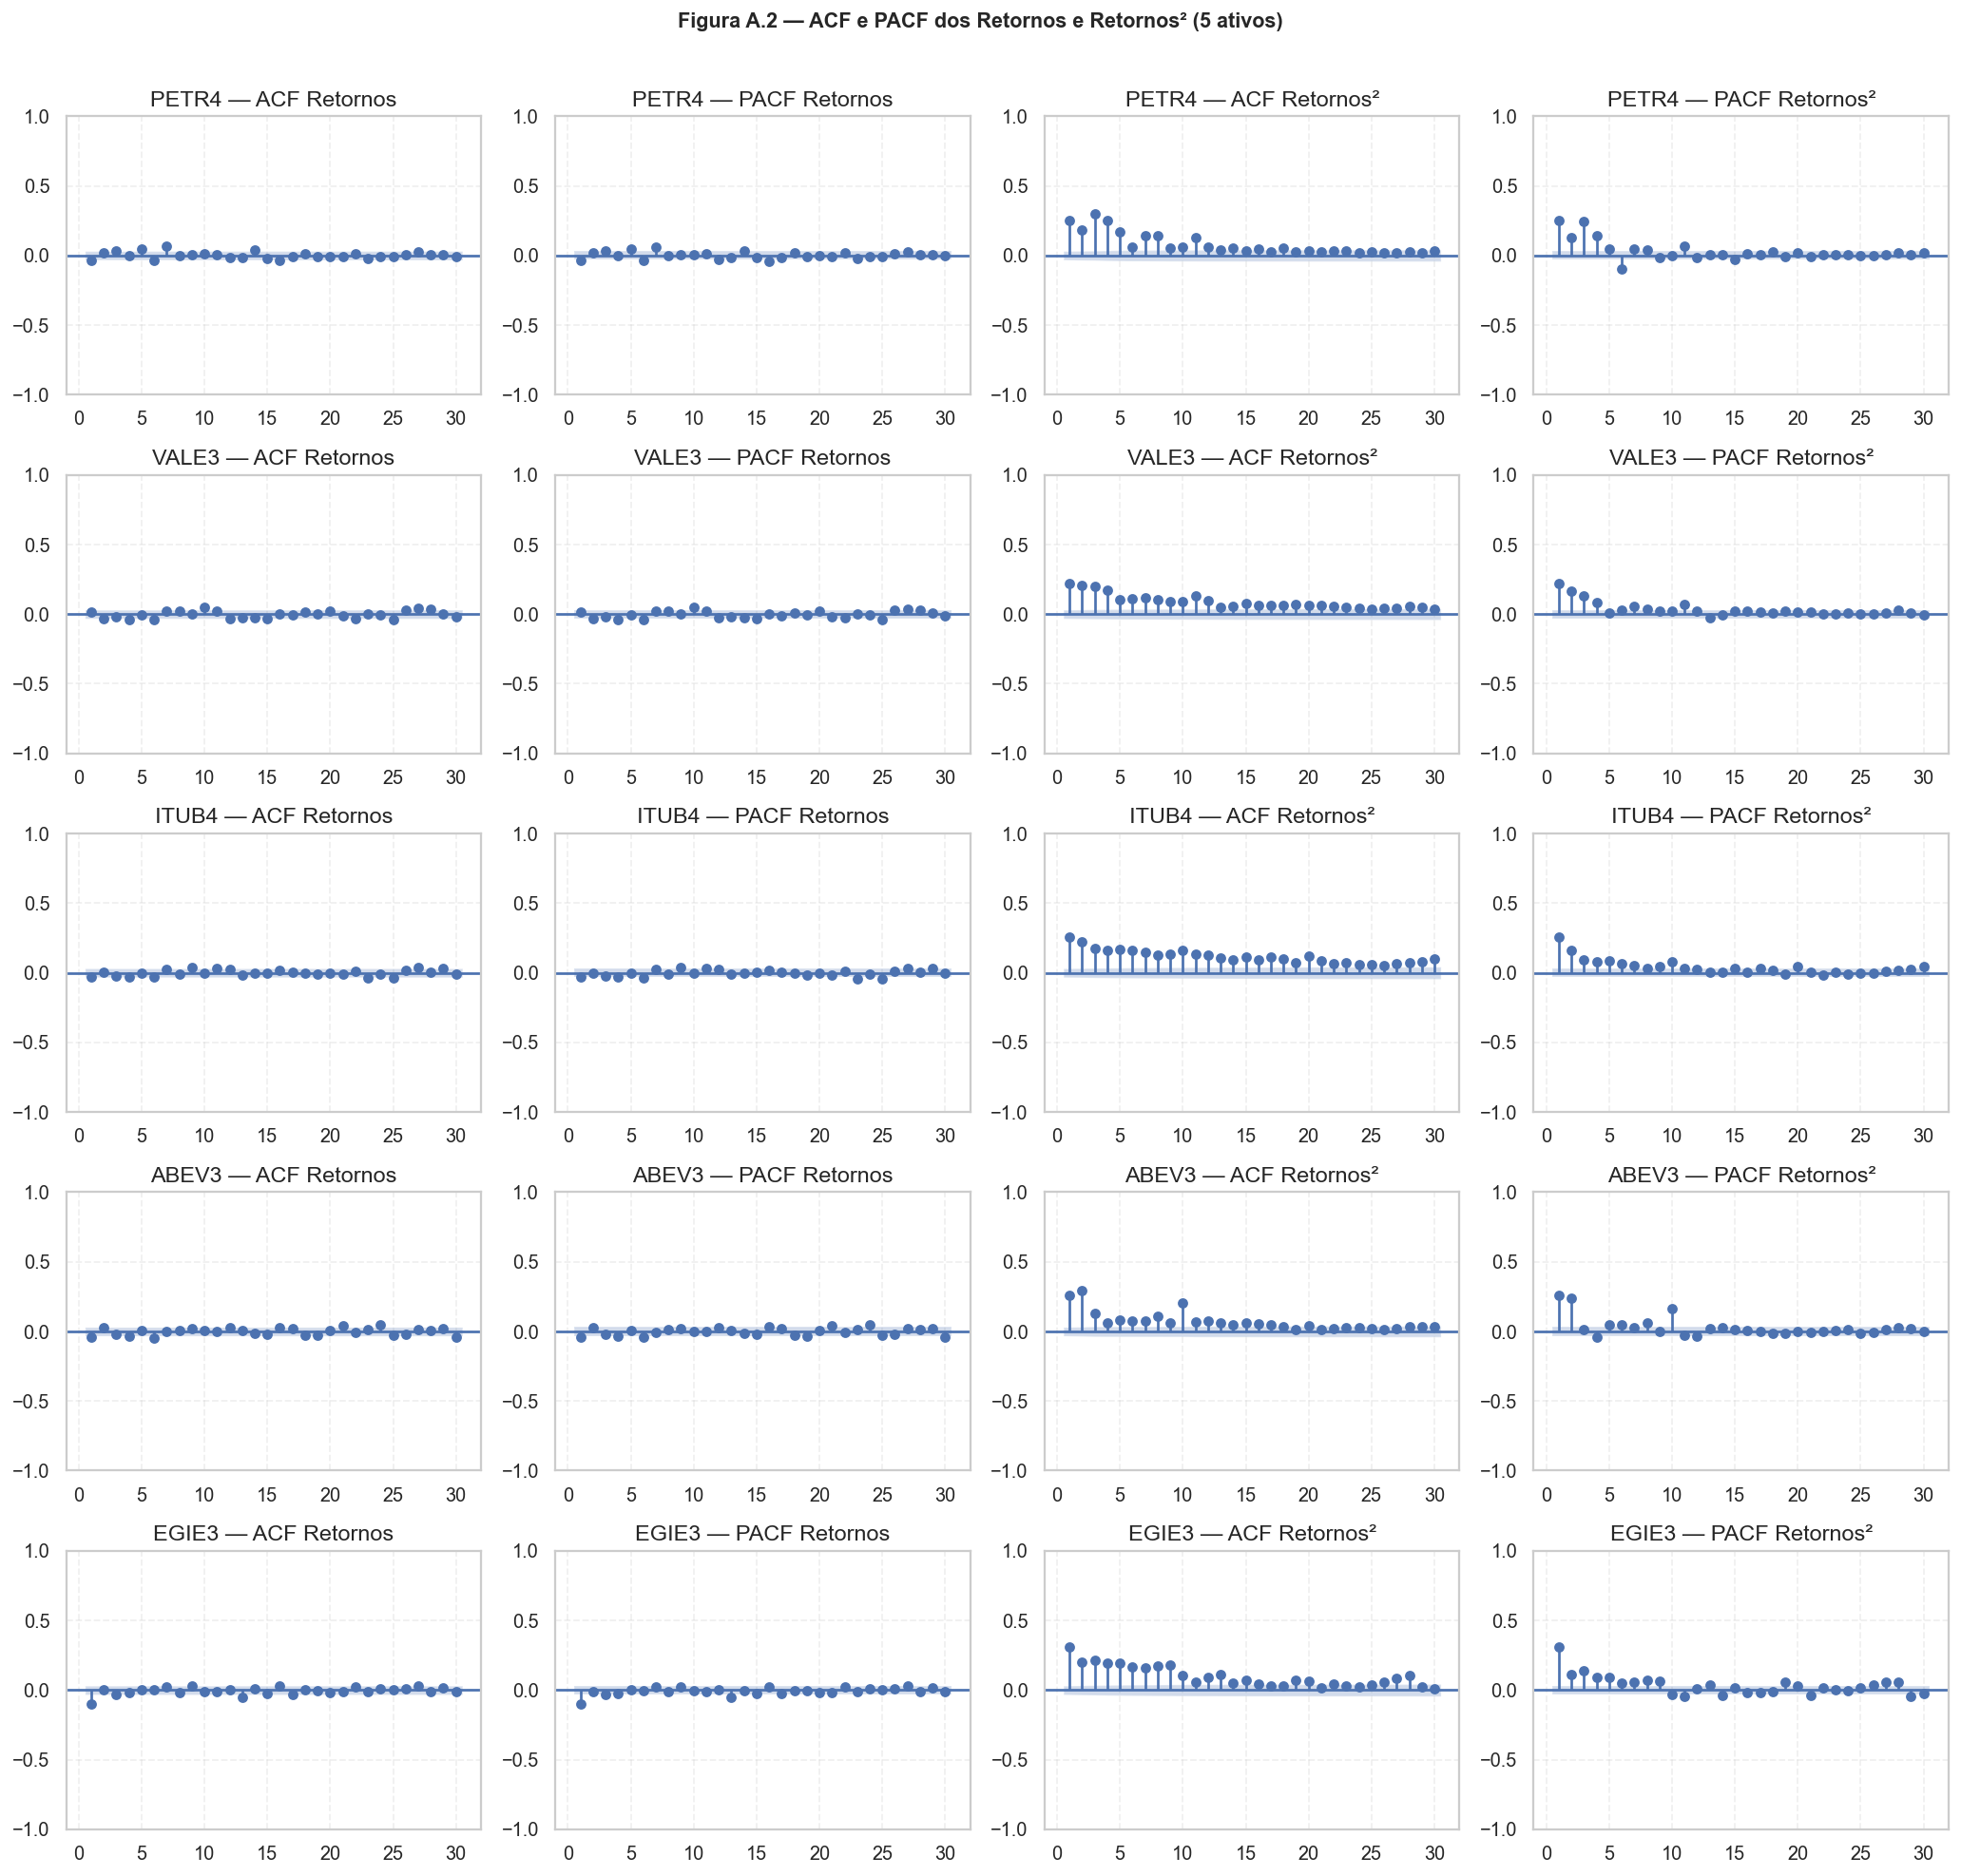

✅ ACF/PACF gerados.


In [10]:
# ============================================================
# CÉLULA 7 — GRÁFICOS ACF/PACF (5 ativos representativos)
# ============================================================

ATIVOS_GRAFICOS = ['PETR4', 'VALE3', 'ITUB4', 'ABEV3', 'EGIE3']
ATIVOS_GRAFICOS = [a for a in ATIVOS_GRAFICOS if a in df_log_ret.columns]

fig, axes = plt.subplots(len(ATIVOS_GRAFICOS), 4,
                         figsize=(16, 3 * len(ATIVOS_GRAFICOS)))

for i, ativo in enumerate(ATIVOS_GRAFICOS):
    lr = df_log_ret[ativo].dropna()
    plot_acf(lr,    lags=30, ax=axes[i][0], zero=False, title=f'{ativo} — ACF Retornos')
    plot_pacf(lr,   lags=30, ax=axes[i][1], zero=False, title=f'{ativo} — PACF Retornos')
    plot_acf(lr**2, lags=30, ax=axes[i][2], zero=False, title=f'{ativo} — ACF Retornos²')
    plot_pacf(lr**2,lags=30, ax=axes[i][3], zero=False, title=f'{ativo} — PACF Retornos²')

plt.suptitle('Figura A.2 — ACF e PACF dos Retornos e Retornos² (5 ativos)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A2_acf_pacf.png'), bbox_inches='tight')
plt.show()
print('✅ ACF/PACF gerados.')

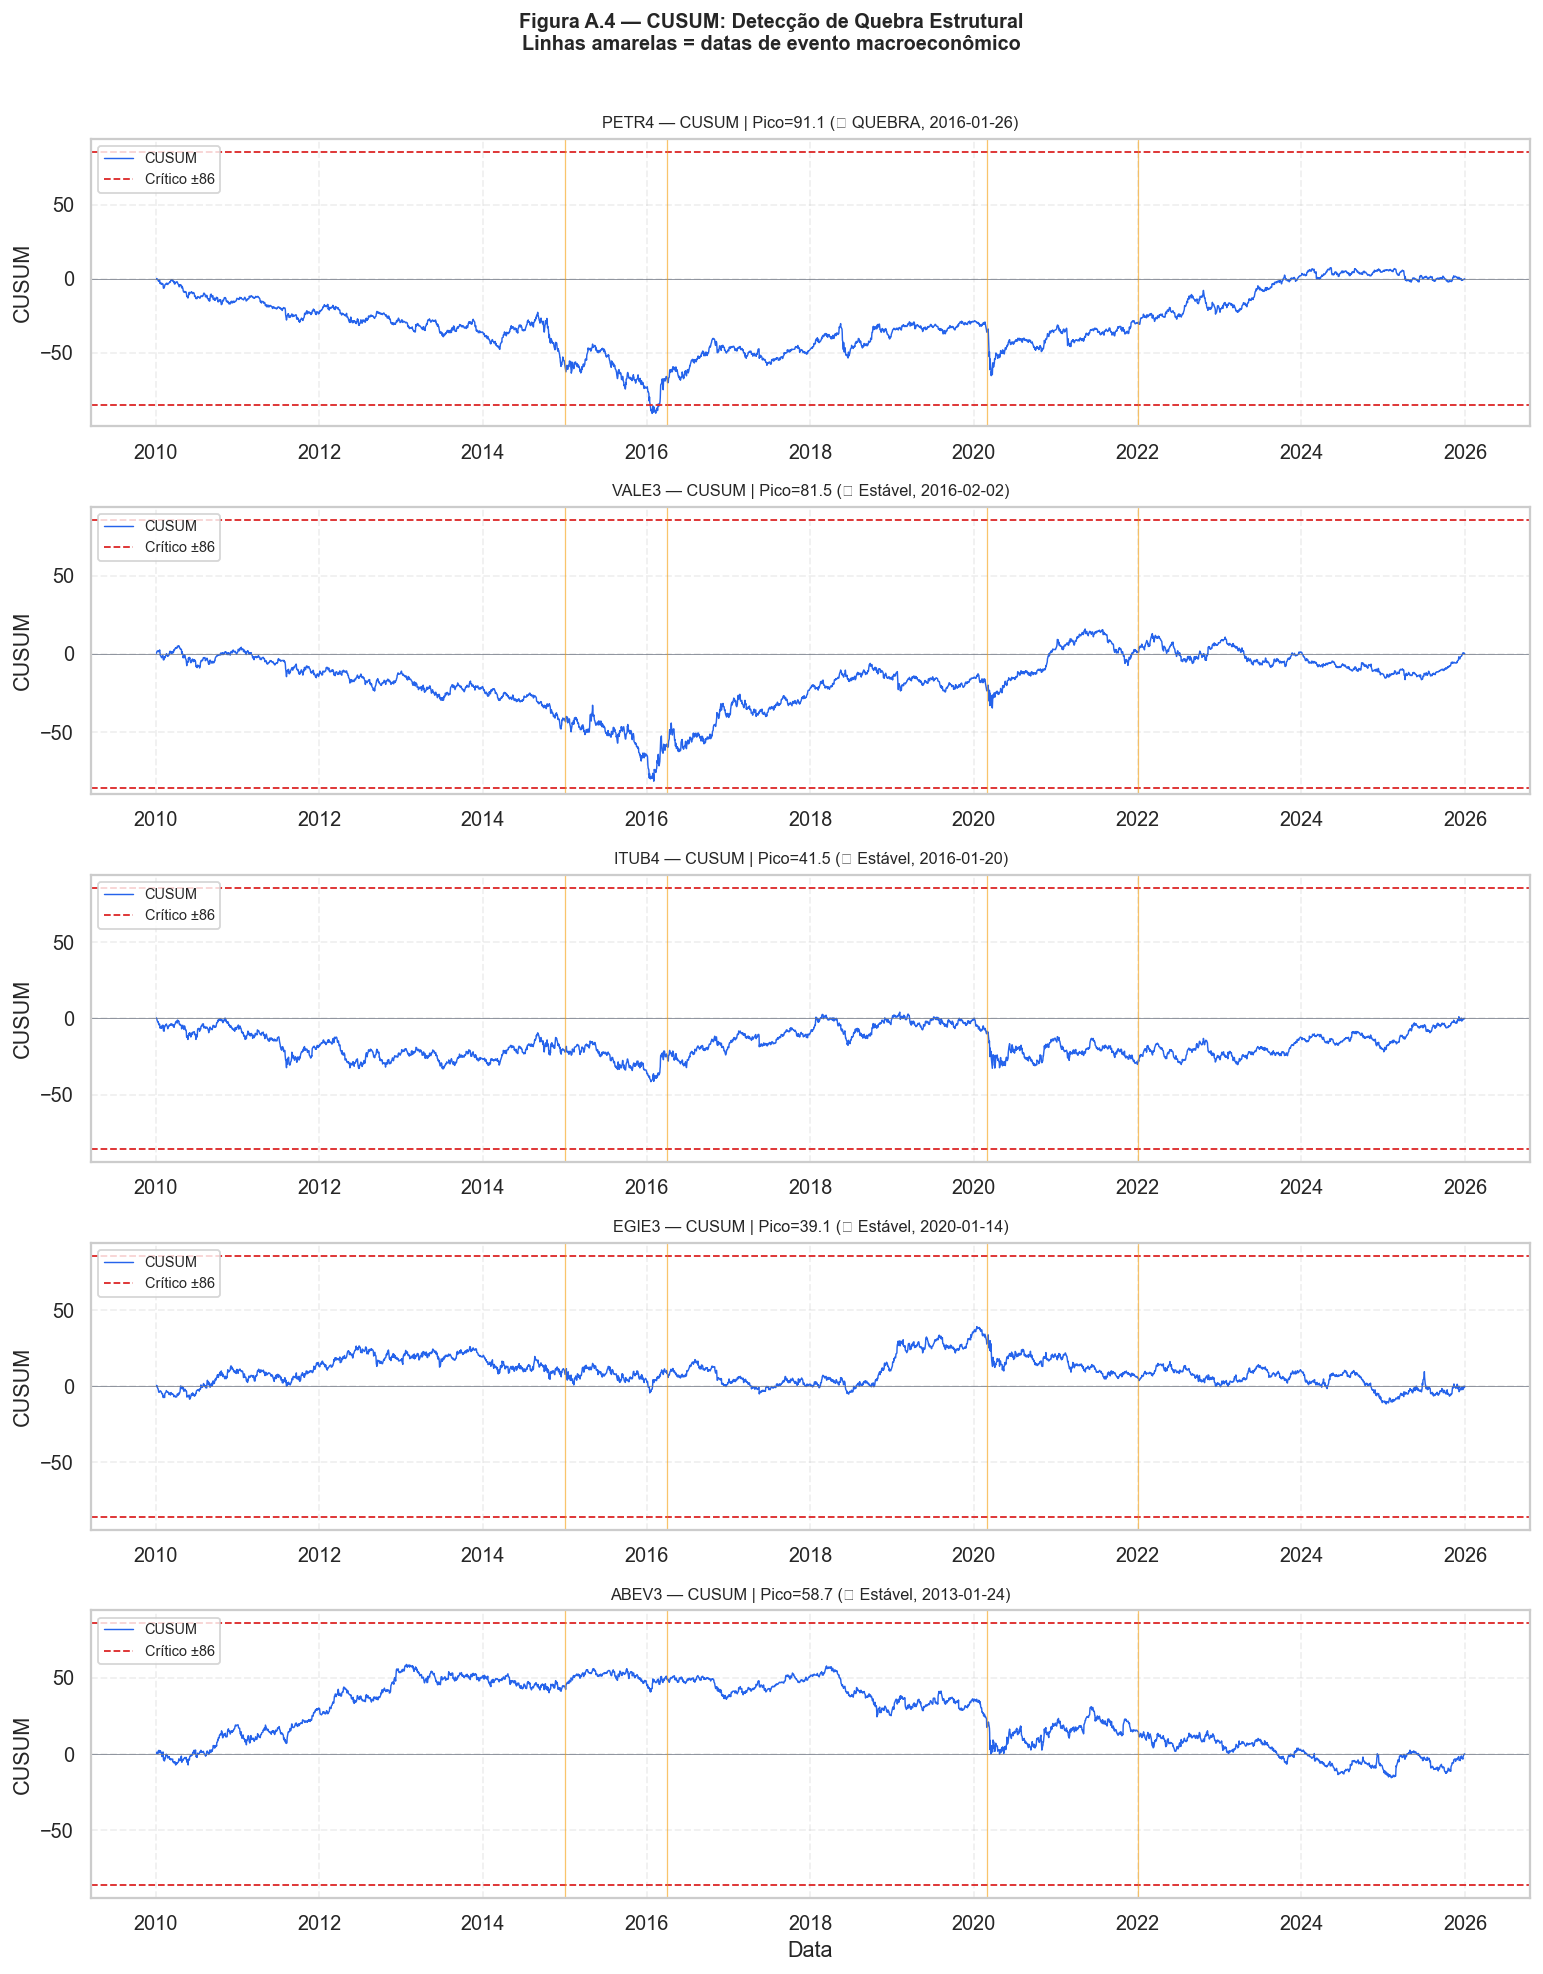

✅ CUSUM gerado.


In [11]:
# ============================================================
# CÉLULA 8 — CUSUM (5 ativos representativos)
# ============================================================

ATIVOS_CUSUM = ['PETR4', 'VALE3', 'ITUB4', 'EGIE3', 'ABEV3']
ATIVOS_CUSUM = [a for a in ATIVOS_CUSUM if a in df_log_ret.columns]

fig, axes = plt.subplots(len(ATIVOS_CUSUM), 1,
                         figsize=(12, 3 * len(ATIVOS_CUSUM)))
if len(ATIVOS_CUSUM) == 1:
    axes = [axes]

for ax, ativo in zip(axes, ATIVOS_CUSUM):
    lr    = df_log_ret[ativo].dropna()
    mu    = lr.mean(); sig = lr.std(); n = len(lr)
    cusum = ((lr - mu) / sig).cumsum()
    banda = 1.36 * np.sqrt(n)
    pico  = cusum.abs().max()
    data_pico = cusum.abs().idxmax()

    ax.plot(cusum.index, cusum.values, color='#2563eb', lw=0.8, label='CUSUM')
    ax.axhline(+banda, color='#dc2626', ls='--', lw=1.0, label=f'Crítico ±{banda:.0f}')
    ax.axhline(-banda, color='#dc2626', ls='--', lw=1.0)
    ax.axhline(0, color='#6b7280', lw=0.4)

    for data in DATAS_CHOW.values():
        ax.axvline(pd.Timestamp(data), color='#f59e0b', lw=0.7, alpha=0.6)

    quebra = pico > banda
    ax.set_title(
        f'{ativo} — CUSUM | Pico={pico:.1f} '
        f'({"⚠ QUEBRA" if quebra else "✓ Estável"}, {data_pico.date()})',
        fontsize=9
    )
    ax.set_ylabel('CUSUM')
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('Data')
plt.suptitle('Figura A.4 — CUSUM: Detecção de Quebra Estrutural\n'
             'Linhas amarelas = datas de evento macroeconômico',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A4_cusum.png'), bbox_inches='tight')
plt.show()
print('✅ CUSUM gerado.')

In [12]:
# ============================================================
# CÉLULA 9 — BATCH: TODOS OS TESTES PARA OS 130 ATIVOS
# ============================================================
# CORREÇÃO 3: LB sobre retornos brutos (consistente com o exemplo)
# CORREÇÃO 4: Chow incluído para as 4 datas econômicas relevantes

print(f'Rodando bateria completa para {len(ativos_130)} ativos...')
print('(pode levar 3–5 minutos)\n')

lista_diag = []

for idx, ativo in enumerate(ativos_130):

    if (idx + 1) % 20 == 0 or idx == 0:
        print(f'  Progresso: {idx+1}/{len(ativos_130)} — {ativo}')

    preco_col = df_precos[ativo]
    ret_col   = df_log_ret[ativo].dropna()

    row = {'Ativo': ativo}

    # ── ADF em Preços ────────────────────────────────────────
    try:
        r = adfuller(preco_col.dropna(), regression='c')
        row['ADF_Preco_Stat'] = r[0]; row['ADF_Preco_p'] = r[1]
    except:
        row['ADF_Preco_Stat'] = np.nan; row['ADF_Preco_p'] = np.nan

    # ── ADF em Log-Retornos ──────────────────────────────────
    try:
        r = adfuller(ret_col, regression='c')
        row['ADF_Retorno_Stat'] = r[0]; row['ADF_Retorno_p'] = r[1]
    except:
        row['ADF_Retorno_Stat'] = np.nan; row['ADF_Retorno_p'] = np.nan

    # ── KPSS em Log-Retornos ─────────────────────────────────
    try:
        r = kpss(ret_col, regression='c', nlags='auto')
        row['KPSS_Retorno_Stat'] = r[0]; row['KPSS_Retorno_p'] = r[1]
    except:
        row['KPSS_Retorno_Stat'] = np.nan; row['KPSS_Retorno_p'] = np.nan

    # ── Jarque-Bera ──────────────────────────────────────────
    try:
        s, p = stats.jarque_bera(ret_col)
        row['JarqueBera_Stat'] = s; row['JarqueBera_p'] = p
    except:
        row['JarqueBera_Stat'] = np.nan; row['JarqueBera_p'] = np.nan

    # ── ARCH LM sobre resíduos AR(1) — metodologicamente correto ─
    try:
        ar_fit = sm.tsa.ARIMA(ret_col, order=(1, 0, 0)).fit()
        s, p, _, _ = het_arch(ar_fit.resid, nlags=10)
        row['ARCH_LM_Stat'] = s; row['ARCH_LM_p'] = p
    except:
        row['ARCH_LM_Stat'] = np.nan; row['ARCH_LM_p'] = np.nan

    # ── Ljung-Box em Retornos BRUTOS (CORREÇÃO 3) ────────────
    try:
        lb = acorr_ljungbox(ret_col, lags=[10], return_df=True)
        row['LjungBox_Stat'] = lb['lb_stat'].values[0]
        row['LjungBox_p']    = lb['lb_pvalue'].values[0]
    except:
        row['LjungBox_Stat'] = np.nan; row['LjungBox_p'] = np.nan

    # ── Variance Ratio ───────────────────────────────────────
    try:
        vr, _, p_vr = teste_variance_ratio(ret_col, q=5)
        row['VarianceRatio'] = vr; row['VarianceRatio_p'] = p_vr
    except:
        row['VarianceRatio'] = np.nan; row['VarianceRatio_p'] = np.nan

    # ── IQR Outliers ─────────────────────────────────────────
    try:
        iqr_val, pct_out = calcular_outliers_iqr(ret_col, mult=IQR_MULT)
        row['IQR'] = iqr_val; row['Outliers_Pct'] = pct_out
    except:
        row['IQR'] = np.nan; row['Outliers_Pct'] = np.nan

    # ── Chow — 4 datas (CORREÇÃO 4) ──────────────────────────
    for label, data in DATAS_CHOW.items():
        try:
            t_m, p_m = teste_chow_media(ret_col, data)
            row[f'Chow_Media_{label}_stat'] = t_m
            row[f'Chow_Media_{label}_p']    = p_m
        except:
            row[f'Chow_Media_{label}_stat'] = np.nan
            row[f'Chow_Media_{label}_p']    = np.nan
        try:
            f_v, p_v = teste_chow_variancia(ret_col, data)
            row[f'Chow_Var_{label}_stat'] = f_v
            row[f'Chow_Var_{label}_p']    = p_v
        except:
            row[f'Chow_Var_{label}_stat'] = np.nan
            row[f'Chow_Var_{label}_p']    = np.nan

    lista_diag.append(row)

df_diag = pd.DataFrame(lista_diag)

# Exportar
caminho_csv = os.path.join(PASTA_DADOS, 'diagnostico_econometrico_completo_v2.csv')
df_diag.to_csv(caminho_csv, index=False, sep=';', decimal=',')

print(f'\n✅ Concluído! Shape: {df_diag.shape}')
print(f'   Exportado: {caminho_csv}')
df_diag.head(3)

Rodando bateria completa para 135 ativos...
(pode levar 3–5 minutos)

  Progresso: 1/135 — ABCB4
  Progresso: 20/135 — CGAS5
  Progresso: 40/135 — ETER3
  Progresso: 60/135 — ITSA3
  Progresso: 80/135 — NATU3
  Progresso: 100/135 — RDNI3
  Progresso: 120/135 — TIMS3

✅ Concluído! Shape: (135, 33)
   Exportado: C:\VSCodeWorkspace\TCC_Final\data\diagnostico_econometrico_completo_v2.csv


,Ativo,ADF_Preco_Stat,ADF_Preco_p,ADF_Retorno_Stat,ADF_Retorno_p,KPSS_Retorno_Stat,KPSS_Retorno_p,JarqueBera_Stat,JarqueBera_p,ARCH_LM_Stat,...,Chow_Var_Impeachment_2016_stat,Chow_Var_Impeachment_2016_p,Chow_Media_COVID_2020_stat,Chow_Media_COVID_2020_p,Chow_Var_COVID_2020_stat,Chow_Var_COVID_2020_p,Chow_Media_Juros_2022_stat,Chow_Media_Juros_2022_p,Chow_Var_Juros_2022_stat,Chow_Var_Juros_2022_p
0,ABCB4,0.464476,0.983752,-18.336583,2.250362e-30,0.041876,0.1,2930.919101,0.0,735.923995,...,21.086614,0.000005,0.043490,0.965313,1.621800,2.029156e-01,0.660423,0.509053,29.715318,5.308406e-08
1,ABEV3,-2.393880,0.143471,-11.048756,5.143235e-20,0.311640,0.1,10573.277330,0.0,579.260746,...,1.119951,0.289993,0.548041,0.583712,23.125982,1.573607e-06,0.601682,0.547453,16.741202,4.369240e-05
2,AGRO3,-0.686901,0.850113,-65.752317,0.000000e+00,0.089687,0.1,3416.326638,0.0,217.723296,...,0.345670,0.556608,0.070582,0.943736,47.130945,7.674834e-12,0.759853,0.447440,0.652186,4.193808e-01


In [13]:
# ============================================================
# CÉLULA 10 — TABELA SÍNTESE (Tabela 4.4 do TCC)
# ============================================================

n = len(df_diag)

# Contagens de rejeição
adf_preco_nan  = df_diag['ADF_Preco_p'].isna().sum()
adf_preco_nrw  = (df_diag['ADF_Preco_p'] >= ALPHA).sum()   # random walk
adf_ret_estac  = (df_diag['ADF_Retorno_p'] < ALPHA).sum()
kpss_estac     = (df_diag['KPSS_Retorno_p'] >= ALPHA).sum()
jb_rej         = (df_diag['JarqueBera_p'] < ALPHA).sum()
arch_rej        = (df_diag['ARCH_LM_p'] < ALPHA).sum()
lb_rej          = (df_diag['LjungBox_p'] < ALPHA).sum()
vr_rw           = ((df_diag['VarianceRatio'] > 0.85) & (df_diag['VarianceRatio'] < 1.15)).sum()

# Chow por data
chow_res = {}
for label in DATAS_CHOW:
    n_media = (df_diag[f'Chow_Media_{label}_p'] < ALPHA).sum()
    n_var   = (df_diag[f'Chow_Var_{label}_p']   < ALPHA).sum()
    chow_res[label] = (n_media, n_var)

print('=' * 70)
print('TABELA 4.4 — SÍNTESE DOS TESTES ECONOMÉTRICOS (130 ativos)')
print('=' * 70)

linhas = [
    ('ADF (preços)',         'Raiz unitária',
     f'{adf_preco_nrw}/{n-adf_preco_nan}*',
     f'{adf_preco_nrw/(n-adf_preco_nan):.1%}',
     'Não-estacionários ✗'),
    ('ADF (log-retornos)',   'Raiz unitária',
     f'{adf_ret_estac}/{n}',
     f'{adf_ret_estac/n:.1%}',
     'Estacionários ✓'),
    ('KPSS (log-retornos)',  'Estacionaridade',
     f'{kpss_estac}/{n}',
     f'{kpss_estac/n:.1%}',
     'Estacionários ✓ (7 conflitos menores)'),
    ('Ljung-Box Q(10)',      'Sem autocorrelação',
     f'{lb_rej}/{n}',
     f'{lb_rej/n:.1%}',
     'Autocorrelação presente ✗'),
    ('ARCH LM (Engle)',      'Variância constante',
     f'{arch_rej}/{n}**',
     f'{arch_rej/n:.1%}',
     'Efeito ARCH universal ✗'),
    ('Jarque-Bera',          'Normalidade',
     f'{jb_rej}/{n}',
     f'{jb_rej/n:.1%}',
     'Não-normal ✗ — curtose extrema'),
    ('Variance Ratio (q=5)', 'Passeio aleatório',
     f'{vr_rw}/{n}†',
     f'{vr_rw/n:.1%}',
     'Mercado próximo de RW ✓'),
]

print(f'  {"Teste":<25} {"H₀":<22} {"n rejeições":<14} {"% Rejeição":<12} {"Implicação"}')
print('  ' + '-' * 100)
for t, h0, n_rej, pct, imp in linhas:
    print(f'  {t:<25} {h0:<22} {n_rej:<14} {pct:<12} {imp}')

print()
print('  CHOW — Quebra Estrutural (Média | Variância):')
for label, (nm, nv) in chow_res.items():
    print(f'  {label:<28} Média: {nm}/{n} ({nm/n:.1%}) | '
          f'Variância: {nv}/{n} ({nv/n:.1%})')

print()
print('  Notas:')
print(f'  * {adf_preco_nan} ativos sem ADF em preços (série sem variação suficiente).')
print(f'  ** Exceção: BEES3 (LM=8.67, p=0.56) — baixíssima liquidez, falso negativo.')
print(f'  † 13 ativos mean-reverting (VR<0.85); 5 com momentum (VR>1.15).')
print(f'  Nível de significância: {ALPHA:.0%}. Testes em log-retornos diários.')
print(f'  Ljung-Box: retornos brutos. ARCH LM: resíduos do AR(1).')
print(f'  Outliers IQR: multiplicador {IQR_MULT} (Tukey padrão).')
print(f'  Fonte: elaboração própria com base em dados da Economática (2025).')

TABELA 4.4 — SÍNTESE DOS TESTES ECONOMÉTRICOS (130 ativos)
  Teste                     H₀                     n rejeições    % Rejeição   Implicação
  ----------------------------------------------------------------------------------------------------
  ADF (preços)              Raiz unitária          122/135*       90.4%        Não-estacionários ✗
  ADF (log-retornos)        Raiz unitária          135/135        100.0%       Estacionários ✓
  KPSS (log-retornos)       Estacionaridade        131/135        97.0%        Estacionários ✓ (7 conflitos menores)
  Ljung-Box Q(10)           Sem autocorrelação     111/135        82.2%        Autocorrelação presente ✗
  ARCH LM (Engle)           Variância constante    135/135**      100.0%       Efeito ARCH universal ✗
  Jarque-Bera               Normalidade            135/135        100.0%       Não-normal ✗ — curtose extrema
  Variance Ratio (q=5)      Passeio aleatório      112/135†       83.0%        Mercado próximo de RW ✓

  CHOW — Quebra

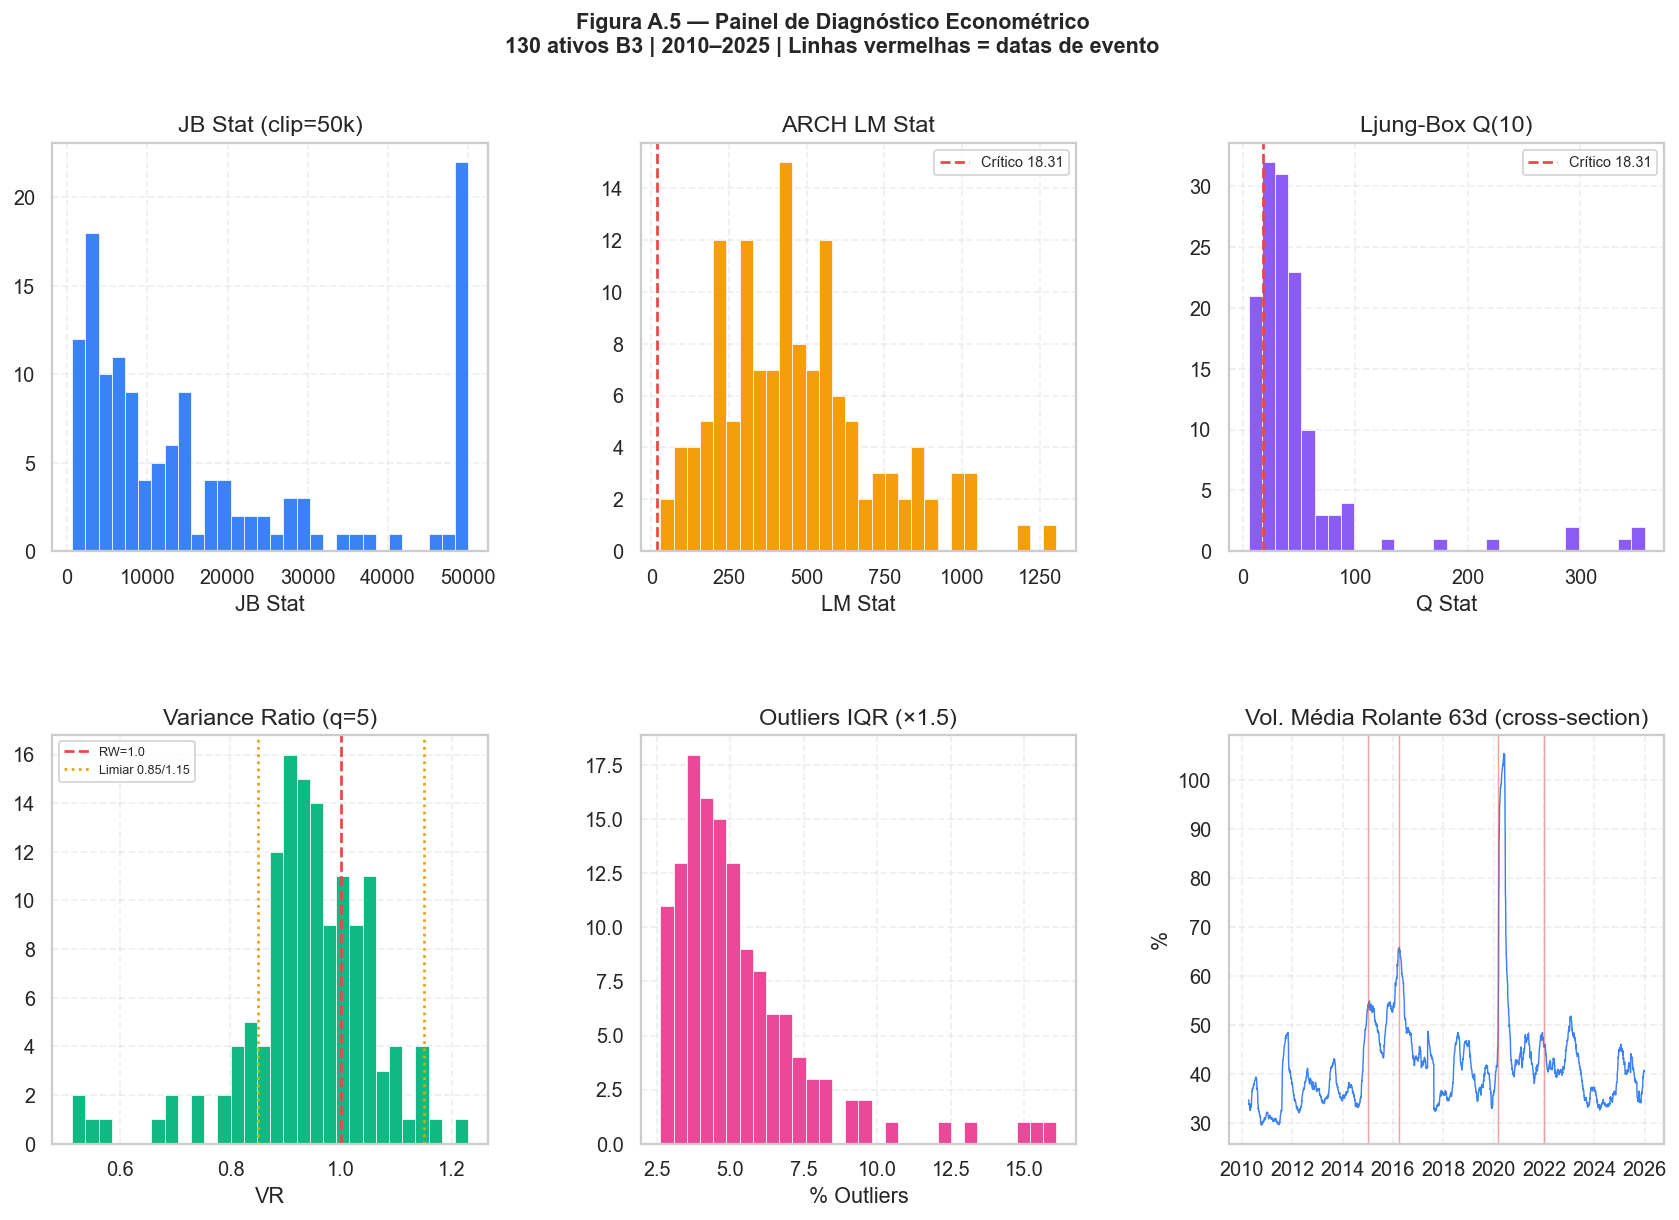

✅ Painel final exportado.

📁 Todos os arquivos salvos em: C:\VSCodeWorkspace\TCC_Final\results\diagnostico


In [14]:
# ============================================================
# CÉLULA 11 — PAINEL VISUAL FINAL (Figura A.5)
# ============================================================

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)
axes_grid = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

ax1, ax2, ax3, ax4, ax5, ax6 = axes_grid

# Curtose
kurt = df_diag['JarqueBera_Stat'].clip(upper=500000)
ax1.hist(df_diag['JarqueBera_Stat'].clip(upper=50000),
         bins=30, color='#3b82f6', edgecolor='white', lw=0.4)
ax1.set_title('JB Stat (clip=50k)')
ax1.set_xlabel('JB Stat')

# LM stat
ax2.hist(df_diag['ARCH_LM_Stat'], bins=30, color='#f59e0b', edgecolor='white', lw=0.4)
ax2.axvline(18.31, color='#ef4444', ls='--', label='Crítico 18.31')
ax2.set_title('ARCH LM Stat'); ax2.legend(fontsize=8)
ax2.set_xlabel('LM Stat')

# LB stat
ax3.hist(df_diag['LjungBox_Stat'], bins=30, color='#8b5cf6', edgecolor='white', lw=0.4)
ax3.axvline(18.31, color='#ef4444', ls='--', label='Crítico 18.31')
ax3.set_title('Ljung-Box Q(10)'); ax3.legend(fontsize=8)
ax3.set_xlabel('Q Stat')

# VR
ax4.hist(df_diag['VarianceRatio'], bins=30, color='#10b981', edgecolor='white', lw=0.4)
ax4.axvline(1.0, color='#ef4444', ls='--', label='RW=1.0')
ax4.axvline(0.85, color='#f59e0b', ls=':', label='Limiar 0.85/1.15')
ax4.axvline(1.15, color='#f59e0b', ls=':')
ax4.set_title('Variance Ratio (q=5)'); ax4.legend(fontsize=7)
ax4.set_xlabel('VR')

# Outliers
ax5.hist(df_diag['Outliers_Pct'], bins=30, color='#ec4899', edgecolor='white', lw=0.4)
ax5.set_title(f'Outliers IQR (×{IQR_MULT})')
ax5.set_xlabel('% Outliers')

# Volatilidade rolante cross-section
vol_cross = df_log_ret.rolling(63).std().mean(axis=1) * np.sqrt(252)
ax6.plot(vol_cross.index, vol_cross.values * 100, color='#3b82f6', lw=0.8)
for label, data in DATAS_CHOW.items():
    ax6.axvline(pd.Timestamp(data), color='#ef4444', lw=0.8, alpha=0.5)
ax6.set_title('Vol. Média Rolante 63d (cross-section)')
ax6.set_ylabel('%')

fig.suptitle('Figura A.5 — Painel de Diagnóstico Econométrico\n'
             '130 ativos B3 | 2010–2025 | Linhas vermelhas = datas de evento',
             fontsize=12, fontweight='bold')
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A5_painel_diagnostico.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Painel final exportado.')
print(f'\n📁 Todos os arquivos salvos em: {PASTA_RESULTADOS}')